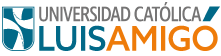

# Universidad Católica Luis Amigó

Curso: Modelamiento y simulación 2026-1

Docente: Juan Carlos Briñez de León


#Regresión por redes neuronales y Deep Learning
#Modelamiento de Series de Tiempo

#1. Datos de trabajo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de parámetros
np.random.seed(42)  # Para que los resultados sean reproducibles
n_puntos = 500
X = np.linspace(0, 10 * np.pi, n_puntos)  # Dos ciclos completos

# 2. Definición de los componentes
amplitud = 10
frecuencia = 1
tendencia_sinusoidal = amplitud * np.sin(frecuencia * X)

# 3. Agregar varianza alta (ruido blanco)
nivel_ruido = 2.0
ruido = np.random.normal(0, nivel_ruido, n_puntos)

# 4. Combinar para obtener la señal final
Y = tendencia_sinusoidal + ruido

# 5. Visualización
plt.figure(figsize=(12, 6))
plt.scatter(X, Y, label='Datos con varianza alta')
plt.xlabel('Tiempo / Fase')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
def Cal_error(Y_prediction,Y):
  MSE=np.mean(np.square(Y_prediction - Y))
  RMSE=np.sqrt(MSE)
  return (MSE,RMSE)

#2. Regresión con Machine Learning

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. DATOS ORIGINALES
X2 = X.reshape(-1, 1)


# 2. PREPARACIÓN DE CARACTERÍSTICAS (Aumento y Escalamiento)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X2)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# 3. ENTRENAMIENTO Y PREDICCIÓN DE MODELOS

# Modelo 1: Polyfit (Numpy)
p3 = np.poly1d(np.polyfit(X.flatten(), Y, 3))
Y_pred_poly = p3(X.flatten())
_,rmse_poly = Cal_error(Y, Y_pred_poly)

# Modelo 2: KNN (k=2)
knn = KNeighborsRegressor(n_neighbors=2)
knn.fit(X_poly_scaled, Y)
Y_pred_knn = knn.predict(X_poly_scaled)
_,rmse_knn = Cal_error(Y, Y_pred_knn)

# Modelo 3: SVR (Support Vector Regression)
svr = SVR(kernel='rbf', C=1.0, epsilon=0.01)
svr.fit(X_poly_scaled, Y)
Y_pred_svr = svr.predict(X_poly_scaled)
_,rmse_svr = Cal_error(Y, Y_pred_svr)

# Modelo 4: Árbol de Decisión
tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X_poly_scaled, Y)
Y_pred_tree = tree.predict(X_poly_scaled)
_,rmse_tree = Cal_error(Y, Y_pred_tree)

# Modelo 5: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_poly_scaled, Y)
Y_pred_rf = rf.predict(X_poly_scaled)
_,rmse_rf = Cal_error(Y, Y_pred_rf)

# 4. VISUALIZACIÓN UNIFICADA
plt.figure(figsize=(12, 7))
plt.scatter(X, Y, color='black',  label='Datos Reales')

plt.plot(X.flatten(), Y_pred_poly.flatten(), label=f'Polyfit G3 (RMSE: {rmse_poly:.3f})', linewidth=2)
plt.plot(X, Y_pred_knn, label=f'KNN k=2 (RMSE: {rmse_knn:.3f})', linewidth=2)
plt.plot(X, Y_pred_svr, label=f'SVR RBF (RMSE: {rmse_svr:.3f})', linewidth=2)
plt.plot(X, Y_pred_tree, label=f'Árbol (RMSE: {rmse_tree:.3f})', linewidth=2)
plt.plot(X, Y_pred_rf, label=f'Random Forest (RMSE: {rmse_rf:.3f})', linewidth=2)

plt.title('Comparativa Monolítica de Modelos de Regresión')
plt.xlabel('Altitud (m)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. REPORTE DE ERRORES
print("-" * 40)
print(f"{'MODELO':<25} | {'RMSE':<10}")
print("-" * 40)
print(f"{'Polyfit (Grado 3)':<25} | {rmse_poly:.4f}")
print(f"{'KNN (k=2)':<25} | {rmse_knn:.4f}")
print(f"{'SVR (RBF)':<25} | {rmse_svr:.4f}")
print(f"{'Árbol de Decisión':<25} | {rmse_tree:.4f}")
print(f"{'Random Forest':<25} | {rmse_rf:.4f}")
print("-" * 40)

#3. Regresión con redes neuronales

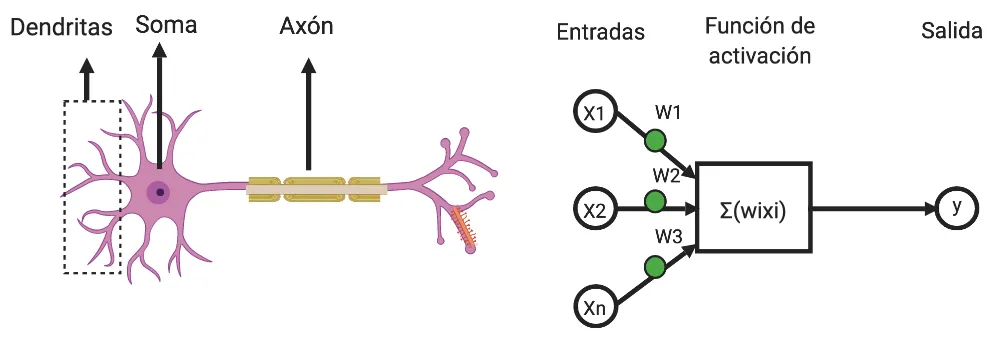

[Clic para ampliar lectura](https://medium.com/futurelabmx/introducci%C3%B3n-a-las-redes-neuronales-pt-i-a73f87933f8e)

Si se asume una sola entrada (La entrada lineal, y el intercepto, como una entrada fija de valor 1), la salida del modelo corresponde con una ecuación lineal. En este caso, los pesos "W" del modelo serían la pendiente y el intercepto.

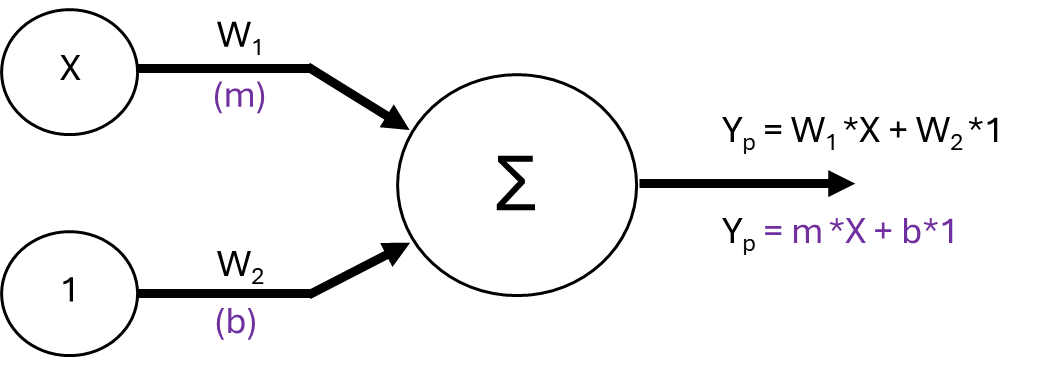

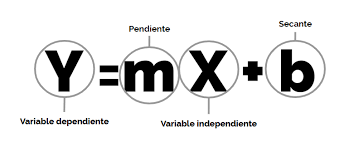

Ahora lo interesante, es encontrar una estrategia donde el algoritmo aprenda a encontrar los pesos del modelo a partir de los datos.

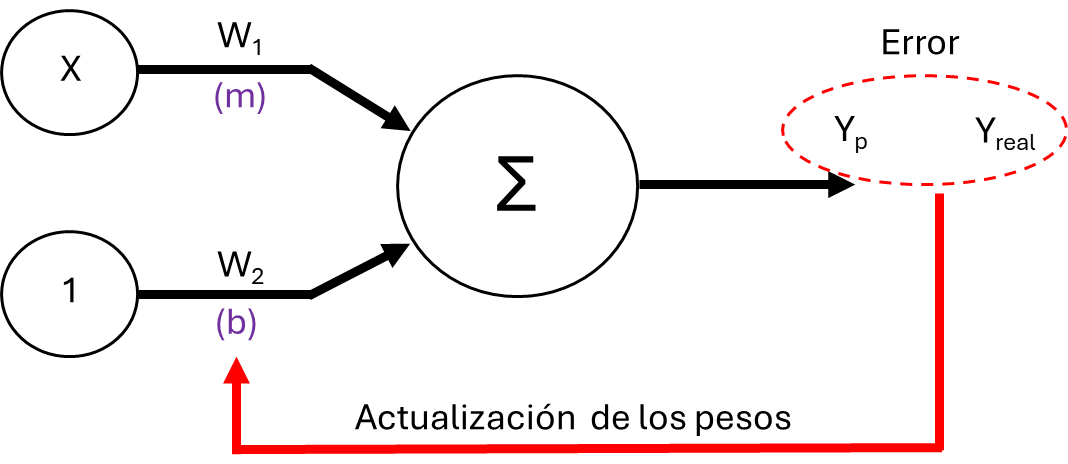

Es por ello que se necesita conocer el error. De tal manera que el valor del error le indique al algoritmo que debe actualizar los pesos en alguna dirección (Gradiente), y que lo debe hacer con alguna velocidad (Tasa de prendizaje).

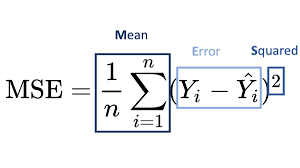

[Para mayor información clic aquí](https://towardsdatascience.com/gradient-descent-from-scratch-e8b75fa986cc)

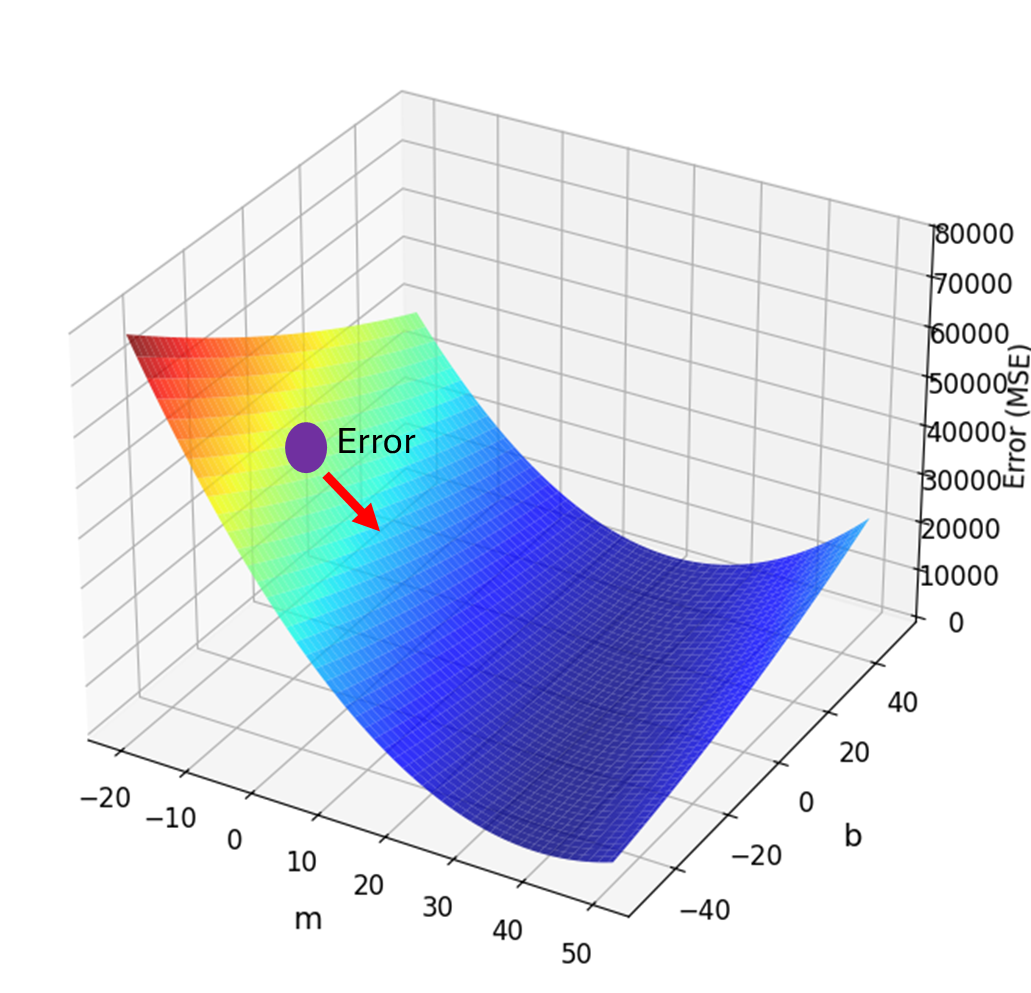

En el aprendizaje automático, las funciones están anidadas por subfunciones internas. Tenemos una función para la predicción, y esa predicción está dentro de una función de pérdida.

Si tenemos $y = f(g(x))$, la derivada no es directa. La Regla de la Cadena nos dice que el cambio total es el producto de los cambios individuales:$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

Para saber cómo un pequeño ajuste en un peso ($m$) afecta al error final ($L$), primero debemos ver cómo ese peso afecta a la predicción ($\hat{y}$), y luego cómo esa predicción afecta al error.

En nuestro caso, el MSE, que penaliza estima los errores de la predicción con respcto a los datos reales, lo representamos como:$$L(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Donde la predicción es:

$$\hat{y}_i = m x_i + b$$

De este modo:
$$L(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (m x_i + b))^2$$

Así, aplicamos la regla de la cadena para derivarla función de rror y calcular el gradiente respecto a la pendiente ($m$), para ello derivamos la "envoltura" externa de la función (el cuadrado) y luego el "contenido" interno (la función lineal) con respecto a ($m$).

Derivada externa, el exponente $2$ baja multiplicando:

$$2(y_i - (m x_i + b))$$

Derivada interna de $(y_i - (m x_i + b))$ respecto a $m$:

$$-x_i$$

Al multiplicar ambas, obtenemos el componente del gradiente para $m$:

$$\frac{\partial L}{\partial m} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot (-x_i) = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - \hat{y}_i)$$

Ahora repetimos el proceso respecto al sesgo ($b$), pero ahora derivamos respecto a $b$.

La derivada interna de $(y_i - (m x_i + b))$ respecto a $b$ es simplemente $-1$.

$$\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot (-1) = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)$$



Estas dos ecuaciones son los componentes de un vector llamado Gradiente ($\nabla L$).

Esto representa la "pendiente" del terreno en el que estamos parados. Si el gradiente es positivo, la montaña sube hacia adelante; entonces para disminuir el error debemos caminar hacia atrás. Si el gradiente es negativo, la montaña baja hacia adelante; entonces para disminuir el error seguimos caminando en esa dirección.

La actualización de los parámetros en cada iteración del código se define entonces como:
$$\omega_{nuevo} = \omega_{anterior} - \alpha \cdot \nabla L$$

Donde $\alpha$ es nuestra tasa de aprendizaje o "tamaño del paso (Learning rate)".

Para la pendiente: $$m_{nuevo} = m_{anterior} - \alpha \left( \frac{\partial L}{\partial m} \right)$$

Para el intercepto: $$b_{nuevo} = b_{anterior} - \alpha \left( \frac{\partial L}{\partial b} \right)$$

In [ ]:
# @title Modelo Polinómico de orden 1 con Gradiente Descendente
X_real = X
Y_real = Y
from google.colab import output #Librería para limpiar la salida
import random

# Como es un modelo lineal, la ecuación modelo es Y=m*X + b, así:
#Valores iniciales
m = random.randint(0, 100)
b = random.randint(0, 100)

# Opciones adicionales
display_step = 50 #Es un comodín para decidir cada cuantas iteraciones deseamos ver los resultados
N = len(X_real)
loss = [] #Pèrdida

# Proceso de optimización
epochs = 500
learning_rate = 0.01
convergence_criteria = 1e-5 #0.00001
for step in range( epochs ):
    # Gradientes iniciales (Zero gradients)
    m_gradient = 0
    b_gradient = 0
    error = 0
    Diferencia = 0

    # Calculamos el error y con ello, el gradiente
    for i in range(N):
      Yp = (m*X_real[i] + b)
      Diferencia = Y_real[i] -Yp
      error += (Diferencia)**2 #MSE
      # Calculamos el gradiente y lo acumulamos en todos los datos
      m_gradient += -(2/N)*(Diferencia)*X_real[i]
      b_gradient += -(2/N)*(Diferencia)*1

    MSE = error/N

    # Actualizamos los valores de acuerdo al gradiente
    m = m - ( m_gradient * learning_rate )
    b = b - ( b_gradient * learning_rate )

    # Guardamos el error por cada epoca
    loss.append( np.abs(MSE))

    # Mostramos cada display_step epocas
    if step % display_step == 0:
        plt.scatter(X_real, Y_real)
        pred_x = [0, max(X_real)]
        pred_y = [m*0+b, m*max(X_real) + b]
        plt.title('Epoca: {0}'.format(step))
        plt.plot(pred_x, pred_y, "r")
        plt.show()
        plt.pause(1)
        output.clear()

    #Paramos el algoritmo cuando los hiperparámetros no estén cambiando lo suficiente
    if max(abs(learning_rate * m_gradient), abs(learning_rate * b_gradient)) < convergence_criteria:
        break


#=============Impresión de los resultados==========
print("Los valores obtenidos son: ", 'm =',m, 'y b =', b)
print("Finalizado en ", step, " iteraciones ")
print('')
Y_prediction4=m * X_real + b
MSE=np.mean(np.square(Y_prediction4 - Y_real))
print('RMSE= ',np.sqrt(MSE))

_, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(X_real, Y_real, c="b"),axes[0].set_title("Datos & Modelo")
axes[0].plot(X_real,Y_prediction4, c="r")
axes[1].plot( loss ), axes[1].set_title("Costo (MSE)")
axes[1].set_xlabel("Epochs"), axes[1].set_ylabel("MSE")
plt.show()

La tasa de aprendizaje ($\alpha$) es el hiperparámetro más crítico en la optimización, pues actúa como el "acelerador" del descenso: una sensibilidad mal calibrada puede arruinar el entrenamiento.

Si $\alpha$ es excesivamente pequeño, el algoritmo se vuelve tedioso y corre el riesgo de quedar atrapado en mínimos locales o mesetas donde el gradiente es casi nulo, tardando una eternidad en llegar al valle.

Por el contrario, si $\alpha$ es demasiado grande, el sistema se vuelve inestable; los pasos son tan amplios que "saltan" por encima del mínimo, provocando que el error oscile violentamente o incluso diverja hacia el infinito, alejándose de la solución.

El escenario ideal es una tasa que permita un descenso fluido y constante, a menudo empezando con pasos firmes y reduciéndose conforme nos acercamos a la base para lograr una convergencia precisa en el punto de menor pérdida.

In [ ]:
# @title Modelo Polinómico de orden 3 con Gradiente Descendente
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output

X_real = X
Y_real = Y

X2 = X_real**2
X3 = X_real**3

# =============================
# Inicialización de parámetros
# =============================
rng = np.random.default_rng()
b0 = rng.normal(0, 0.1)   # valores iniciales pequeños
b1 = rng.normal(0, 0.1)
b2 = rng.normal(0, 0.1)
b3 = rng.normal(0, 0.1)

# =============================
# Entrenamiento
# =============================
epochs = 10000
learning_rate = 1e-5  # mucho más pequeño para evitar divergencia
convergence_criteria = 1e-6
loss = []
N = len(X_real)

for step in range(epochs):
    # Gradientes acumulados
    b0_gradient = 0
    b1_gradient = 0
    b2_gradient = 0
    b3_gradient = 0
    error = 0

    for i in range(N):
        Yp = b0 + b1*X_real[i] + b2*X2[i] + b3*X3[i]
        Diferencia = Y_real[i] - Yp
        error += Diferencia**2

        b0_gradient += -(2/N)*Diferencia
        b1_gradient += -(2/N)*Diferencia*X_real[i]
        b2_gradient += -(2/N)*Diferencia*X2[i]
        b3_gradient += -(2/N)*Diferencia*X3[i]

    MSE = error/N

    # Actualización de parámetros
    b0 = b0 - learning_rate * b0_gradient
    b1 -= learning_rate * b1_gradient
    b2 -= learning_rate * b2_gradient
    b3 -= learning_rate * b3_gradient

    loss.append(MSE)

    # Mostrar cada cierto número de épocas
    if step % 500 == 0:
        plt.scatter(X_real, Y_real)
        X_grid = np.linspace(min(X_real), max(X_real), 200)
        Y_grid = b0 + b1*X_grid + b2*X_grid**2 + b3*X_grid**3
        plt.plot(X_grid, Y_grid, "r")
        plt.title(f'Época: {step}')
        plt.show()
        plt.pause(1)
        output.clear()

    # Criterio de convergencia
    if max(abs(learning_rate * b0_gradient),
           abs(learning_rate * b1_gradient),
           abs(learning_rate * b2_gradient),
           abs(learning_rate * b3_gradient)) < convergence_criteria:
        break

# =============================
# Resultados finales
# =============================
print(f"Coeficientes finales: b0={b0:.6f}, b1={b1:.6f}, b2={b2:.6f}, b3={b3:.6f}")
print("Finalizado en ", step, " iteraciones")

Y_prediction = b0 + b1*X_real + b2*X2 + b3*X3
MSE = np.mean((Y_prediction - Y_real)**2)
print("RMSE =", np.sqrt(MSE))

# Gráficas finales
_, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(X_real, Y_real, c="b"), axes[0].set_title("Datos & Modelo")
axes[0].plot(X_real, Y_prediction, "-r")
axes[1].plot(loss), axes[1].set_title("Costo (MSE)")
axes[1].set_xlabel("Epochs"), axes[1].set_ylabel("MSE")
plt.show()


In [ ]:
# @title Modelo Polinómico de orden 3 con Gradiente Descendente (Normalizando datos)
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output

# =============================
# Preparación de datos
# =============================
X_real = X
Y_real = Y

# Normalizar X para mejorar estabilidad numérica
X_norm = (X_real - np.mean(X_real)) / np.std(X_real)

X2 = X_norm**2
X3 = X_norm**3

# =============================
# Inicialización de parámetros
# =============================
rng = np.random.default_rng()
b0 = rng.normal(0, 0.1)   # coeficientes iniciales pequeños
b1 = rng.normal(0, 0.1)
b2 = rng.normal(0, 0.1)
b3 = rng.normal(0, 0.1)

# =============================
# Entrenamiento
# =============================
epochs = 1000
learning_rate = 0.01
convergence_criteria = 1e-6
loss = []
N = len(X_real)

for step in range(epochs):
    # Gradientes acumulados
    b0_gradient = 0
    b1_gradient = 0
    b2_gradient = 0
    b3_gradient = 0
    error = 0

    for i in range(N):
        Yp = b0 + b1*X_norm[i] + b2*X2[i] + b3*X3[i]
        Diferencia = Yp - Y_real[i]
        error += Diferencia**2

        b0_gradient += (2/N)*Diferencia
        b1_gradient += (2/N)*Diferencia*X_norm[i]
        b2_gradient += (2/N)*Diferencia*X2[i]
        b3_gradient += (2/N)*Diferencia*X3[i]

    MSE = error/N

    # Actualización de parámetros
    b0 -= learning_rate * b0_gradient
    b1 -= learning_rate * b1_gradient
    b2 -= learning_rate * b2_gradient
    b3 -= learning_rate * b3_gradient

    loss.append(MSE)

    # Mostrar cada cierto número de épocas
    if step % 100 == 0:
        plt.scatter(X_norm, Y_real, c="b")
        X_grid = np.linspace(min(X_norm), max(X_norm), 200)
        Y_grid = b0 + b1*X_grid + b2*X_grid**2 + b3*X_grid**3
        plt.plot(X_grid, Y_grid, "r")
        plt.title(f'Época: {step}')
        plt.show()
        plt.pause(1)
        output.clear()

    # Criterio de convergencia
    if max(abs(learning_rate * b0_gradient),
           abs(learning_rate * b1_gradient),
           abs(learning_rate * b2_gradient),
           abs(learning_rate * b3_gradient)) < convergence_criteria:
        break

# =============================
# Resultados finales
# =============================
print(f"Coeficientes finales: b0={b0:.4f}, b1={b1:.4f}, b2={b2:.4f}, b3={b3:.4f}")
print("Finalizado en ", step, " iteraciones")

Y_prediction = b0 + b1*X_norm + b2*X2 + b3*X3
MSE = np.mean((Y_prediction - Y_real)**2)
print("RMSE =", np.sqrt(MSE))

# Gráficas finales
_, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(X_norm, Y_real, c="b"), axes[0].set_title("Datos & Modelo")
axes[0].plot(X_norm, Y_prediction, "-r")
axes[1].plot(loss), axes[1].set_title("Costo (MSE)")
axes[1].set_xlabel("Epochs"), axes[1].set_ylabel("MSE")
plt.show()


Ahora de grado 15

In [ ]:
# @title Modelo Polinómico de Grado 15 (Versión Estable - No NaN)
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
import time

# =============================
# Preparación de datos
# =============================
X_real = X
Y_real = Y

# Normalización estricta
X_mean = np.mean(X_real)
X_std = np.std(X_real)
X_norm = (X_real - X_mean) / X_std

# Potencias
X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15 = [X_norm**i for i in range(2, 16)]

# =============================
# Inicialización de parámetros
# =============================
rng = np.random.default_rng(42)
# Usamos una escala muy pequeña para evitar que el polinomio "salte" al infinito
escala = 0.001
b0, b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, b14, b15 = rng.uniform(-escala, escala, 16)

# =============================
# Entrenamiento
# =============================
epochs = 10000
learning_rate = 0.0001 # Muy bajo para evitar NaN
loss = []
N = len(X_real)

for step in range(epochs):
    # Inicializar gradientes
    b0_g = b1_g = b2_g = b3_g = b4_g = b5_g = b6_g = b7_g = b8_g = b9_g = b10_g = b11_g = b12_g = b13_g = b14_g = b15_g = 0
    error_acumulado = 0

    # Bucle de cálculo
    for i in range(N):
        Yp = (b0 + b1*X_norm[i] + b2*X2[i] + b3*X3[i] + b4*X4[i] + b5*X5[i] +
              b6*X6[i] + b7*X7[i] + b8*X8[i] + b9*X9[i] + b10*X10[i] +
              b11*X11[i] + b12*X12[i] + b13*X13[i] + b14*X14[i] + b15*X15[i])

        diff = Yp - Y_real[i]
        error_acumulado += diff**2

        # Gradientes
        common = (2/N) * diff
        b0_g += common
        b1_g += common * X_norm[i]
        b2_g += common * X2[i]
        b3_g += common * X3[i]
        b4_g += common * X4[i]
        b5_g += common * X5[i]
        b6_g += common * X6[i]
        b7_g += common * X7[i]
        b8_g += common * X8[i]
        b9_g += common * X9[i]
        b10_g += common * X10[i]
        b11_g += common * X11[i]
        b12_g += common * X12[i]
        b13_g += common * X13[i]
        b14_g += common * X14[i]
        b15_g += common * X15[i]

    MSE = error_acumulado / N
    loss.append(MSE)

    # --- PROTECCIÓN ANTI-NaN (Gradient Clipping) ---
    # Si el gradiente es muy grande, lo limitamos
    limite = 1.0
    # (Esto se aplica mentalmente a cada b_g para no ensuciar el código,
    # pero aquí lo actualizamos directamente)

    # Actualización de parámetros
    b0 -= learning_rate * np.clip(b0_g, -limite, limite)
    b1 -= learning_rate * np.clip(b1_g, -limite, limite)
    b2 -= learning_rate * np.clip(b2_g, -limite, limite)
    b3 -= learning_rate * np.clip(b3_g, -limite, limite)
    b4 -= learning_rate * np.clip(b4_g, -limite, limite)
    b5 -= learning_rate * np.clip(b5_g, -limite, limite)
    b6 -= learning_rate * np.clip(b6_g, -limite, limite)
    b7 -= learning_rate * np.clip(b7_g, -limite, limite)
    b8 -= learning_rate * np.clip(b8_g, -limite, limite)
    b9 -= learning_rate * np.clip(b9_g, -limite, limite)
    b10 -= learning_rate * np.clip(b10_g, -limite, limite)
    b11 -= learning_rate * np.clip(b11_g, -limite, limite)
    b12 -= learning_rate * np.clip(b12_g, -limite, limite)
    b13 -= learning_rate * np.clip(b13_g, -limite, limite)
    b14 -= learning_rate * np.clip(b14_g, -limite, limite)
    b15 -= learning_rate * np.clip(b15_g, -limite, limite)

    if step % 1000 == 0:
        plt.scatter(X_norm, Y_real, c="b", alpha=0.5)
        X_grid = np.linspace(min(X_norm), max(X_norm), 200)
        Y_grid = (b0 + b1*X_grid + b2*X_grid**2 + b3*X_grid**3 + b4*X_grid**4 +
                  b5*X_grid**5 + b6*X_grid**6 + b7*X_grid**7 + b8*X_grid**8 +
                  b9*X_grid**9 + b10*X_grid**10 + b11*X_grid**11 + b12*X_grid**12 +
                  b13*X_grid**13 + b14*X_grid**14 + b15*X_grid**15)
        plt.plot(X_grid, Y_grid, "r")
        plt.title(f"Época {step} - MSE {MSE:.4f}")
        plt.show()
        time.sleep(0.5)
        output.clear()

# =============================
# Resultados finales
# =============================
print(f"Entrenamiento finalizado en {step} épocas")
Y_final = (b0 + b1*X_norm + b2*X2 + b3*X3 + b4*X4 + b5*X5 + b6*X6 + b7*X7 +
           b8*X8 + b9*X9 + b10*X10 + b11*X11 + b12*X12 + b13*X13 + b14*X14 + b15*X15)

plt.figure(figsize=(10, 5))
plt.scatter(X_norm, Y_real, label="Real")
# Ordenar para que la línea no se vea cruzada
indices = np.argsort(X_norm)
plt.plot(X_norm[indices], Y_final[indices], 'r', label="Modelo Grado 15")
plt.legend()
plt.show()

##Modelo con función de activación:

una red neuronal real, la salida no es simplemente la función lineal, sino que pasa por una función de activación $\sigma$. Esto nos permite resolver problemas que no son simples líneas rectas.

Supongamos que nuestra nueva predicción es:

$$\hat{y}_i = \sigma(z_i) \quad \text{donde} \quad z_i = m x_i + b$$

Aquí, la Regla de la Cadena se vuelve más profunda, pues tenemos tres capas: la pérdida, la activación y la combinación lineal.
* La Función de Pérdida con Activación: El MSE se mantiene igual, pero la "predicción" ahora es más compleja:
$$L(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \sigma(m x_i + b))^2$$
* Derivada respecto a la pendiente ($m$): Para derivar respecto a $m$, debemos aplicar la regla de la cadena en tres pasos:

    Externa (Potencia): Derivada del cuadrado $\rightarrow 2(y_i - \hat{y}_i)$.

    Intermedia (Activación): Derivada de la función de activación respecto a su entrada $\rightarrow \sigma'(z_i)$.

    Interna (Lineal): Derivada de $z_i = mx_i + b$ respecto a $m \rightarrow -x_i$.

    Multiplicando los tres eslabones de la cadena:
$$\frac{\partial L}{\partial m} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot \sigma'(z_i) \cdot (-x_i)$$$$\frac{\partial L}{\partial m} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \sigma'(z_i) x_i$$

* Derivada respecto al sesgo ($b$)Repetimos la lógica, pero en el tercer paso (derivada interna), la derivada de $z_i$ respecto a $b$ es $-1$.$$\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot \sigma'(z_i) \cdot (-1)$$$$\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \sigma'(z_i)$$

El impacto de $\sigma'(z)$ en el aprendizajeLa elección de la función de activación altera drásticamente la "geometría" de nuestra superficie de pérdida:

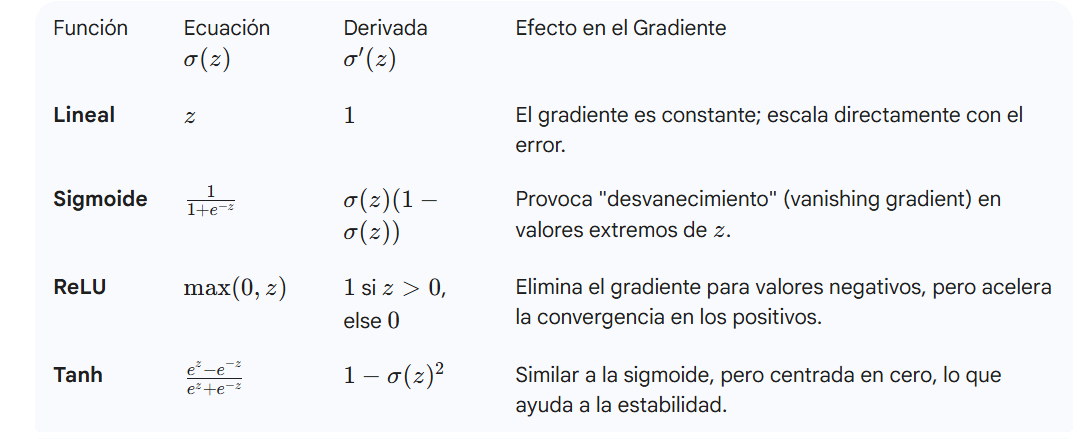

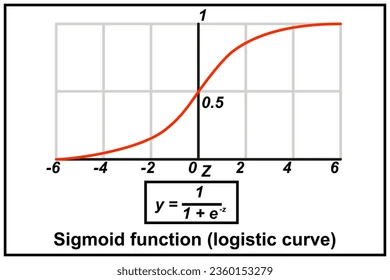

In [ ]:
# @title Modelo Polinómico de orden 1 con Gradiente Descendente y Activación Sigmoide
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
import random

# ==========================
# Datos de entrada
# ==========================
X_real = X
Y_real = Y

# Normalizamos Y a [0,1] porque usaremos sigmoide
Y_min, Y_max = np.min(Y_real), np.max(Y_real)
Y_norm = (Y_real - Y_min) / (Y_max - Y_min)

# ==========================
# Función de activación
# ==========================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Derivada de la sigmoide
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# ==========================
# Inicialización de parámetros
# ==========================
m = random.uniform(-1, 1)
b = random.uniform(-1, 1)

# Opciones adicionales
display_step = 100
N = len(X_real)
loss = []

epochs = 3000
learning_rate = 0.1
convergence_criteria = 1e-5

# ==========================
# Entrenamiento
# ==========================
for step in range(epochs):
    m_gradient = 0
    b_gradient = 0
    error = 0

    # Paso por todos los datos
    for i in range(N):
        z = m*X_real[i] + b
        Yp = sigmoid(z)

        Diferencia = Y_norm[i] - Yp
        error += (Diferencia)**2

        # Aplicamos regla de la cadena:
        dz = Diferencia * sigmoid_derivative(z)

        # Gradientes
        m_gradient += -(2/N) * dz * X_real[i]
        b_gradient += -(2/N) * dz * 1

    MSE = error / N
    loss.append(MSE)

    # Actualización
    m -= learning_rate * m_gradient
    b -= learning_rate * b_gradient

    # Mostrar progreso
    if step % display_step == 0:
        plt.scatter(X_real, Y_norm, label="Datos reales")

        # Graficamos la curva completa
        X_sorted = np.linspace(min(X_real), max(X_real), 200)
        Yp_curve = sigmoid(m*X_sorted + b)

        plt.title(f"Época: {step}")
        plt.plot(X_sorted, Yp_curve, "r", label="Modelo sigmoide")
        plt.legend()
        plt.show()
        plt.pause(1)
        output.clear()

    # Criterio de parada
    if max(abs(learning_rate * m_gradient), abs(learning_rate * b_gradient)) < convergence_criteria:
        break

# ==========================
# Resultados finales
# ==========================
print("Valores finales: m =", m, "b =", b)
print("Finalizado en ", step, " iteraciones")

# Predicciones (re-escaladas al rango original)
Y_pred_norm = sigmoid(m*X_real + b)
Y_pred = Y_pred_norm * (Y_max - Y_min) + Y_min

MSE = np.mean(np.square(Y_pred - Y_real))
print("RMSE =", np.sqrt(MSE))

# Gráficos finales
_, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(X_real, Y_real, c="b"), axes[0].set_title("Datos & Modelo con Sigmoide")
axes[0].plot(X_real, Y_pred, c="r")
axes[1].plot(loss), axes[1].set_title("Costo (MSE normalizado)")
axes[1].set_xlabel("Epochs"), axes[1].set_ylabel("MSE")
plt.show()


In [ ]:
# @title Modelo Polinómico de orden 3 con Gradiente Descendente y Sigmoide (con normalización)
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
import time

# =============================
# Normalización de X
# =============================
X_mean = np.mean(X)
X_std = np.std(X)
X_norm = (X - X_mean) / X_std   # z-score

# Escalamiento de Y a [0,1]
Y_min, Y_max = np.min(Y), np.max(Y)
Y_real = (Y - Y_min) / (Y_max - Y_min)

# Variables polinómicas
X2 = X_norm**2
X3 = X_norm**3

# =============================
# Inicialización de parámetros
# =============================
rng = np.random.default_rng()
b0 = rng.normal(0, 0.1)
b1 = rng.normal(0, 0.1)
b2 = rng.normal(0, 0.1)
b3 = rng.normal(0, 0.1)

# Función de activación sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# =============================
# Entrenamiento
# =============================
epochs = 5000
learning_rate = 1e-1
convergence_criteria = 1e-6
loss = []
N = len(X_norm)

for step in range(epochs):
    b0_gradient = 0
    b1_gradient = 0
    b2_gradient = 0
    b3_gradient = 0
    error = 0

    for i in range(N):
        z = b0 + b1*X_norm[i] + b2*X2[i] + b3*X3[i]
        Yp = sigmoid(z)
        Diferencia = Y_real[i] - Yp
        error += Diferencia**2

        grad_common = -(2/N) * Diferencia * Yp * (1 - Yp)

        b0_gradient += grad_common
        b1_gradient += grad_common * X_norm[i]
        b2_gradient += grad_common * X2[i]
        b3_gradient += grad_common * X3[i]

    MSE = error/N

    # Actualización
    b0 -= learning_rate * b0_gradient
    b1 -= learning_rate * b1_gradient
    b2 -= learning_rate * b2_gradient
    b3 -= learning_rate * b3_gradient

    loss.append(MSE)

    # Mostrar actualización
    if step % 500 == 0:
        output.clear()
        plt.figure(figsize=(6,4))
        plt.scatter(X_norm, Y_real, c="b", label="Datos")
        X_grid = np.linspace(min(X_norm), max(X_norm), 200)
        Z_grid = b0 + b1*X_grid + b2*X_grid**2 + b3*X_grid**3
        Y_grid = sigmoid(Z_grid)
        plt.plot(X_grid, Y_grid, "r", label="Modelo")
        plt.title(f'Época: {step} - MSE: {MSE:.4f}')
        plt.legend()
        plt.show()
        time.sleep(1)

    if max(abs(learning_rate * b0_gradient),
           abs(learning_rate * b1_gradient),
           abs(learning_rate * b2_gradient),
           abs(learning_rate * b3_gradient)) < convergence_criteria:
        break

# =============================
# Resultados finales
# =============================
output.clear()
print(f"Coeficientes finales: b0={b0:.6f}, b1={b1:.6f}, b2={b2:.6f}, b3={b3:.6f}")
print("Finalizado en ", step, " iteraciones")

# Predicciones en la escala original
Y_prediction = sigmoid(b0 + b1*X_norm + b2*X2 + b3*X3)
Y_pred_original = Y_prediction * (Y_max - Y_min) + Y_min

MSE = np.mean((Y_pred_original - Y)**2)
print("RMSE =", np.sqrt(MSE))

# Gráficas finales
_, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(X, Y, c="b"), axes[0].set_title("Datos originales & Modelo")
axes[0].plot(X, Y_pred_original, c="r")
axes[1].plot(loss), axes[1].set_title("Costo (MSE)")
axes[1].set_xlabel("Epochs"), axes[1].set_ylabel("MSE")
plt.show()

## Varias capas en una red neuronal


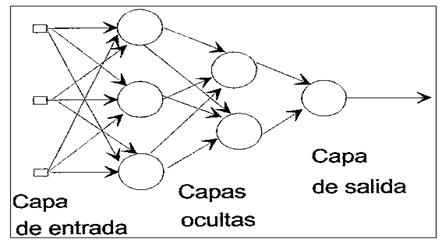

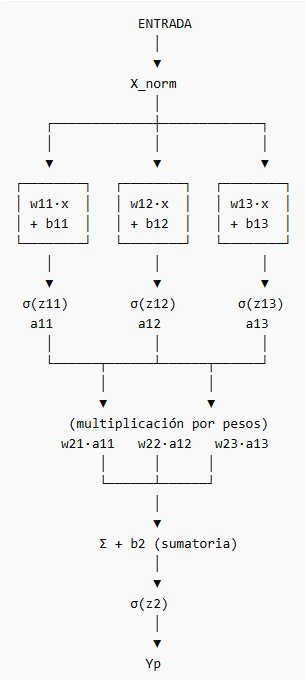

En una red con una capa oculta, la predicción final $\hat{y}$ depende de las activaciones de las neuronas anteriores ($a_h$).

La estructura se ve así:Capa de Salida: $\hat{y} = \sigma(z_{out})$ donde $z_{out} = w_{out} \cdot a_h + b_{out}$

Capa Oculta: $a_h = \sigma(z_h)$ donde $z_h = w_h \cdot x + b_h$

Derivada para los pesos de salida ($w_{out}$): Es idéntica a la que explicaste, porque estos pesos están "justo detrás" de la función de pérdida:$$\frac{\partial L}{\partial w_{out}} = \underbrace{2(y_i - \hat{y}_i)}_{\text{Externa}} \cdot \underbrace{\sigma'(z_{out})}_{\text{Intermedia}} \cdot \underbrace{(-a_h)}_{\text{Interna}}$$

Derivada para los pesos ocultos ($w_h$): Aquí es donde la "cadena" se alarga. Para llegar a $w_h$, el error debe viajar desde la salida, pasar por la neurona de salida, cruzar el peso $w_{out}$ y entrar en la neurona oculta:

Paso 1 (Error de salida): $2(y_i - \hat{y}_i) \cdot \sigma'(z_{out})$

Paso 2 (Influencia del peso de conexión): Se multiplica por $-w_{out}$ (porque el error fluye a través de este cable).

Paso 3 (Activación oculta): Derivada de la sigmoide de la capa oculta $\rightarrow \sigma'(z_h)$.

Paso 4 (Entrada lineal): Derivada de $z_h$ respecto a $w_h \rightarrow x_i$.

Si multiplicamos todos los eslabones:$$\frac{\partial L}{\partial w_h} = \underbrace{2(y_i - \hat{y}_i) \sigma'(z_{out}) \cdot (-w_{out})}_{\text{Propagación del error}} \cdot \underbrace{\sigma'(z_h)}_{\text{Activación local}} \cdot \underbrace{x_i}_{\text{Entrada}}$$

In [ ]:
#Programa de red
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
import time

# =============================
# Preparación de datos
# =============================
X_mean, X_std = np.mean(X), np.std(X)
X_norm = (X - X_mean) / X_std
Y_min, Y_max = np.min(Y), np.max(Y)
Y_real = (Y - Y_min) / (Y_max - Y_min)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# =============================
# Inicialización de parámetros
# =============================
rng = np.random.default_rng()
# CAPA 1 (Oculta: 3 neuronas) - Pesos (w) y Sesgos (b)
# Cada neurona recibe X_norm
w11, b11 = rng.normal(0, 0.5), rng.normal(0, 0.1)
w12, b12 = rng.normal(0, 0.5), rng.normal(0, 0.1)
w13, b13 = rng.normal(0, 0.5), rng.normal(0, 0.1)

# CAPA 2 (Salida: 1 neurona) - Pesos que reciben de la capa 1
w21, w22, w23, b2 = rng.normal(0, 0.5), rng.normal(0, 0.5), rng.normal(0, 0.5), rng.normal(0, 0.1)

# ============= Entrenamiento =============
epochs = 10000
learning_rate = 0.5 # Las redes requieren un rate mayor si usamos sigmoide
loss = []
N = len(X_norm)

for step in range(epochs):
    # Acumuladores de gradientes
    dw11, db11 = 0, 0
    dw12, db12 = 0, 0
    dw13, db13 = 0, 0
    dw21, dw22, dw23, db2_g = 0, 0, 0, 0
    error_total = 0

    for i in range(N):
        # 1. FORWARD PASS
        # Capa Oculta
        z11 = w11 * X_norm[i] + b11
        a11 = sigmoid(z11)
        z12 = w12 * X_norm[i] + b12
        a12 = sigmoid(z12)
        z13 = w13 * X_norm[i] + b13
        a13 = sigmoid(z13)

        # Capa de Salida
        z2 = w21*a11 + w22*a12 + w23*a13 + b2
        Yp = sigmoid(z2)

        diff = Yp - Y_real[i]
        error_total += diff**2

        # 2. BACKPROPAGATION (Cálculo de gradientes manual)
        # Gradiente en la salida
        delta_out = 2 * diff * Yp * (1 - Yp)

        db2_g += delta_out / N
        dw21 += (delta_out * a11) / N
        dw22 += (delta_out * a12) / N
        dw23 += (delta_out * a13) / N

        # Gradientes en la capa oculta (propagando el error hacia atrás)
        delta11 = delta_out * w21 * a11 * (1 - a11)
        dw11 += (delta11 * X_norm[i]) / N
        db11 += delta11 / N

        delta12 = delta_out * w22 * a12 * (1 - a12)
        dw12 += (delta12 * X_norm[i]) / N
        db12 += delta12 / N

        delta13 = delta_out * w23 * a13 * (1 - a13)
        dw13 += (delta13 * X_norm[i]) / N
        db13 += delta13 / N

    MSE = error_total / N
    loss.append(MSE)

    # 3. ACTUALIZACIÓN
    w21 -= learning_rate * dw21; w22 -= learning_rate * dw22; w23 -= learning_rate * dw23; b2 -= learning_rate * db2_g
    w11 -= learning_rate * dw11; b11 -= learning_rate * db11
    w12 -= learning_rate * dw12; b12 -= learning_rate * db12
    w13 -= learning_rate * dw13; b13 -= learning_rate * db13

    if step % 1000 == 0:
        output.clear()
        # Generar curva suave para visualización
        X_grid = np.linspace(min(X_norm), max(X_norm), 100)
        Y_grid = []
        for xg in X_grid:
            a_h1 = sigmoid(w11*xg + b11); a_h2 = sigmoid(w12*xg + b12); a_h3 = sigmoid(w13*xg + b13)
            Y_grid.append(sigmoid(w21*a_h1 + w22*a_h2 + w23*a_h3 + b2))

        plt.scatter(X_norm, Y_real, alpha=0.5)
        plt.plot(X_grid, Y_grid, 'r', lw=2)
        plt.title(f"Red Neuronal - Época {step} - MSE {MSE:.4f}")
        plt.show()

# =============================
# Resultados finales
# =============================
print(f"Entrenamiento completado en {step} épocas")

In [ ]:
# @title Red Neuronal de 2 Capas con Entradas x, x^2, x^3
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
import time

# =============================
# Preparación de datos
# =============================
X_mean, X_std = np.mean(X), np.std(X)
X_norm = (X - X_mean) / X_std
X2, X3 = X_norm**2, X_norm**3  # Generamos las potencias

Y_min, Y_max = np.min(Y), np.max(Y)
Y_real = (Y - Y_min) / (Y_max - Y_min)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# =============================
# Inicialización de parámetros
# =============================
rng = np.random.default_rng()
# CAPA OCULTA (2 neuronas para simplificar la explicación)
# Cada neurona recibe 3 entradas (x, x2, x3) -> 3 pesos por neurona
w11_1, w11_2, w11_3, b11 = rng.normal(0, 0.5, 4) # Neurona 1
w12_1, w12_2, w12_3, b12 = rng.normal(0, 0.5, 4) # Neurona 2

# CAPA DE SALIDA (1 neurona)
# Recibe las activaciones de las 2 neuronas ocultas
w21, w22, b2 = rng.normal(0, 0.5, 3)

# ============= Entrenamiento =============
epochs = 8000
learning_rate = 0.3
loss = []
N = len(X_norm)

for step in range(epochs):
    # Gradientes
    dw11_1, dw11_2, dw11_3, db11 = 0, 0, 0, 0
    dw12_1, dw12_2, dw12_3, db12 = 0, 0, 0, 0
    dw21, dw22, db2_g = 0, 0, 0
    error_total = 0

    for i in range(N):
        # 1. FORWARD PASS
        # Capa Oculta (Combinación lineal de x, x2, x3)
        z11 = w11_1*X_norm[i] + w11_2*X2[i] + w11_3*X3[i] + b11
        a11 = sigmoid(z11)
        z12 = w12_1*X_norm[i] + w12_2*X2[i] + w12_3*X3[i] + b12
        a12 = sigmoid(z12)

        # Capa de Salida
        z2 = w21*a11 + w22*a12 + b2
        Yp = sigmoid(z2)

        diff = Yp - Y_real[i]
        error_total += diff**2

        # 2. BACKPROPAGATION
        # Eslabón Externo + Intermedio (Salida)
        delta_out = 2 * diff * Yp * (1 - Yp)

        dw21 += (delta_out * a11) / N
        dw22 += (delta_out * a12) / N
        db2_g += delta_out / N

        # Eslabón Interno (Capa Oculta) - Propagamos delta_out
        # Neurona 1
        delta11 = delta_out * w21 * a11 * (1 - a11)
        dw11_1 += (delta11 * X_norm[i]) / N
        dw11_2 += (delta11 * X2[i]) / N
        dw11_3 += (delta11 * X3[i]) / N
        db11 += delta11 / N

        # Neurona 2
        delta12 = delta_out * w22 * a12 * (1 - a12)
        dw12_1 += (delta12 * X_norm[i]) / N
        dw12_2 += (delta12 * X2[i]) / N
        dw12_3 += (delta12 * X3[i]) / N
        db12 += delta12 / N

    MSE = error_total / N
    loss.append(MSE)

    # 3. ACTUALIZACIÓN
    w21 -= learning_rate * dw21; w22 -= learning_rate * dw22; b2 -= learning_rate * db2_g
    w11_1 -= learning_rate * dw11_1; w11_2 -= learning_rate * dw11_2; w11_3 -= learning_rate * dw11_3; b11 -= learning_rate * db11
    w12_1 -= learning_rate * dw12_1; w12_2 -= learning_rate * dw12_2; w12_3 -= learning_rate * dw12_3; b12 -= learning_rate * db12

    if step % 1000 == 0:
        output.clear()
        X_grid = np.linspace(min(X_norm), max(X_norm), 100)
        XG2, XG3 = X_grid**2, X_grid**3
        Y_grid = []
        for j in range(len(X_grid)):
            ah1 = sigmoid(w11_1*X_grid[j] + w11_2*XG2[j] + w11_3*XG3[j] + b11)
            ah2 = sigmoid(w12_1*X_grid[j] + w12_2*XG2[j] + w12_3*XG3[j] + b12)
            Y_grid.append(sigmoid(w21*ah1 + w22*ah2 + b2))

        plt.scatter(X_norm, Y_real, alpha=0.4)
        plt.plot(X_grid, Y_grid, 'r', lw=2)
        plt.title(f"Red Neuronal Polinómica - Época {step}")
        plt.show()

print(f"Finalizado. MSE Final: {loss[-1]:.6f}")

Ahora con Tensorflow

In [ ]:
# @title Red Neuronal Secuencial (x, x^2, x^3)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from google.colab import output
import warnings

warnings.filterwarnings('ignore')


# =============================
# Preparación de datos
# =============================
X_mean, X_std = np.mean(X), np.std(X)
X_norm = (X - X_mean) / X_std

# Creamos el vector de entrada con 3 columnas: [x, x^2, x^3]
X_input = np.column_stack([X_norm, X_norm**2, X_norm**3])

Y_min, Y_max = np.min(Y), np.max(Y)
Y_real = (Y - Y_min) / (Y_max - Y_min)

# =============================
# Definición del Modelo Secuencial
# =============================
model = Sequential([
    # Capa Oculta: 3 neuronas, recibe 3 entradas (x, x2, x3)
    tf.keras.layers.Dense(3, activation='sigmoid', input_shape=(3,)),
    # Capa de Salida: 1 neurona
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Configuración del optimizador (Gradiente Descendente)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.5)
model.compile(optimizer=optimizer, loss='mse')

# =============================
# Entrenamiento
# =============================
history = model.fit(X_input, Y_real, epochs=1000, verbose=1)

# =============================
# Visualización de Resultados
# =============================
X_grid = np.linspace(min(X_norm), max(X_norm), 100)
X_grid_input = np.column_stack([X_grid, X_grid**2, X_grid**3])
Y_grid = model.predict(X_grid_input)

plt.figure(figsize=(12, 5))

# Subplot 1: Ajuste
plt.subplot(1, 2, 1)
plt.scatter(X_norm, Y_real, alpha=0.4, label="Datos")
plt.plot(X_grid, Y_grid, 'r', lw=3, label="Modelo Secuencial")
plt.title("Ajuste de la Red Neuronal")
plt.legend()

# Subplot 2: Curva de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title("Evolución del MSE")
plt.xlabel("Epochs")
plt.show()

In [ ]:
# @title Red Neuronal Secuencial (x, x^2, x^3)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from google.colab import output
import warnings

warnings.filterwarnings('ignore')

# =============================
# Preparación de datos
# =============================
X_mean, X_std = np.mean(X), np.std(X)
X_norm = (X - X_mean) / X_std

# Creamos el vector de entrada con 3 columnas: [x, x^2, x^3]
X_input = np.column_stack([X_norm, X_norm**2, X_norm**3])

Y_min, Y_max = np.min(Y), np.max(Y)
Y_real = (Y - Y_min) / (Y_max - Y_min)

# =============================
# Definición del Modelo Secuencial
# =============================
model = Sequential([
    # Capa Oculta 1: 16 neuronas con activación ReLU
    layers.Dense(16, activation='relu', input_shape=(3,)),
    # Capa Oculta 2: 32 neuronas
    layers.Dense(32, activation='relu'),
    # Capa Oculta 3: 16 neuronas
    layers.Dense(16, activation='relu'),
    # Capa de Salida: 1 neurona (Sigmoide para rango [0,1])
    layers.Dense(1, activation='sigmoid')
])

# Configuración del optimizador (Adam es ideal para redes profundas)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse')

# =============================
# Entrenamiento
# =============================
# Entrenamos con un número suficiente de épocas para ajustar las capas adicionales
history = model.fit(X_input, Y_real, epochs=2000, verbose=1)

# =============================
# Visualización de Resultados
# =============================
X_grid = np.linspace(min(X_norm), max(X_norm), 200)
X_grid_input = np.column_stack([X_grid, X_grid**2, X_grid**3])
Y_grid = model.predict(X_grid_input)

plt.figure(figsize=(12, 5))

# Subplot 1: Ajuste
plt.subplot(1, 2, 1)
plt.scatter(X_norm, Y_real, alpha=0.4, label="Datos", c="blue")
plt.plot(X_grid, Y_grid, 'r', lw=3, label="Red Profunda")
plt.title("Ajuste de la Red Neuronal (Multicapa)")
plt.legend()

# Subplot 2: Curva de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title("Evolución del MSE")
plt.xlabel("Epochs")
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.show()

Más información [aquí](https://grupo.us.es/gtocoma/pid/pid10/RedesNeuronales.htm)

#4. Deep Learning for Regressions

El Deep Learning (Aprendizaje Profundo) ha transformado la manera en que abordamos los problemas de regresión, especialmente cuando la relación entre las variables no puede ser capturada por una simple línea recta o una parábola estándar.

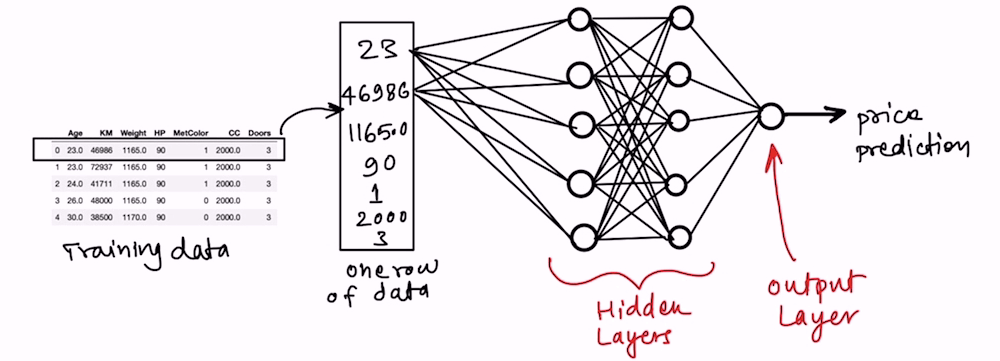

Mientras que la regresión lineal clásica busca encontrar el mejor ajuste mediante una ecuación predefinida, el Deep Learning permite que el modelo "aprenda" la forma de la función directamente de los datos, sin que nosotros tengamos que especificar si es un polinomio de grado 2, 15 o una combinación trigonométrica compleja.

Conceptos Fundamentales en Regresión con Deep Learning:

1. De la Neurona al MulticapaEn regresión, una sola neurona actúa como un regresor lineal. Sin embargo, al apilar múltiples capas (arquitecturas Deep), cada capa realiza una transformación no lineal de las entradas. Esto permite que la red descomponga un problema complejo en pequeñas piezas más simples.

2. Funciones de Activación: El ingrediente no linealSin funciones de activación, una red neuronal de mil capas seguiría siendo una simple regresión lineal. Funciones como ReLU ($f(z) = \max(0, z)$) o Sigmoide introducen la capacidad de "doblar" y "curvar" la línea de ajuste, permitiendo que el modelo se adapte a picos, valles y cambios bruscos de tendencia.

3. El Espacio de Características (Feature Engineering)En los ejemplos que hemos trabajado, le entregamos a la red $x, x^2, x^3$ de forma manual. En el Deep Learning avanzado, la red es capaz de generar sus propias combinaciones de características a partir de los datos brutos. A esto se le llama aprendizaje de representaciones, donde las primeras capas extraen rasgos básicos y las últimas construyen la predicción final.

In [ ]:
# @title Arquitectura de Deep Learning para Regresión No Lineal
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from google.colab import output
import warnings

warnings.filterwarnings('ignore')

# =============================
# 1. Procesamiento de Tensores (Data Prep)
# =============================
X_mean, X_std = np.mean(X), np.std(X)
X_norm = (X - X_mean) / X_std

# Definimos el Feature Space (x, x^2, x^3)
X_input = np.column_stack([X_norm, X_norm**2, X_norm**3])

Y_min, Y_max = np.min(Y), np.max(Y)
Y_target = (Y - Y_min) / (Y_max - Y_min)

# =============================
# 2. Diseño de la Red Neuronal Profunda
# =============================
# Construimos una topología MLP (Multilayer Perceptron)
model = Sequential([
    # Capa de Entrada y Primera Capa Oculta
    layers.Dense(64, activation='relu', input_shape=(3,), name="Input_Layer"),

    # Capas Ocultas Profundas (Deep Layers)
    layers.Dense(128, activation='relu', name="Hidden_Layer_1"),
    layers.Dense(64, activation='relu', name="Hidden_Layer_2"),
    layers.Dense(32, activation='relu', name="Hidden_Layer_3"),

    # Capa de Salida (Output Layer)
    layers.Dense(1, activation='sigmoid', name="Output_Layer")
])

# =============================
# 3. Configuración del Aprendizaje (Compilación)
# =============================
# Utilizamos Adam: un optimizador con momentos y tasa de aprendizaje adaptativa
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

# =============================
# 4. Ciclo de Entrenamiento (Training Loop)
# =============================
# El modelo ajusta sus pesos mediante Backpropagation
history = model.fit(
    X_input,
    Y_target,
    epochs=1500,
    batch_size=32,
    verbose=1
)

# =============================
# 5. Inferencia y Visualización
# =============================
X_grid = np.linspace(min(X_norm), max(X_norm), 300)
X_grid_input = np.column_stack([X_grid, X_grid**2, X_grid**3])
Y_pred = model.predict(X_grid_input)

plt.figure(figsize=(14, 6))

# Visualización del Ajuste del Modelo
plt.subplot(1, 2, 1)
plt.scatter(X_norm, Y_target, alpha=0.3, label="Datos de Entrenamiento", c="#3498db")
plt.plot(X_grid, Y_pred, color="#e74c3c", lw=4, label="Aproximación Deep Learning")
plt.title("Capacidad de Representación de la Red Profunda")
plt.xlabel("Input Feature Space")
plt.ylabel("Target (Normalized)")
plt.legend()
plt.grid(True, alpha=0.3)

# Curva de Convergencia (Loss Landscape)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color="#2ecc71", lw=2)
plt.title("Optimización de la Función de Pérdida (MSE)")
plt.xlabel("Épocas de Entrenamiento")
plt.ylabel("Error Cuadrático Medio")
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#5. Modelamiento de series de tiempo: Metodología de regresión

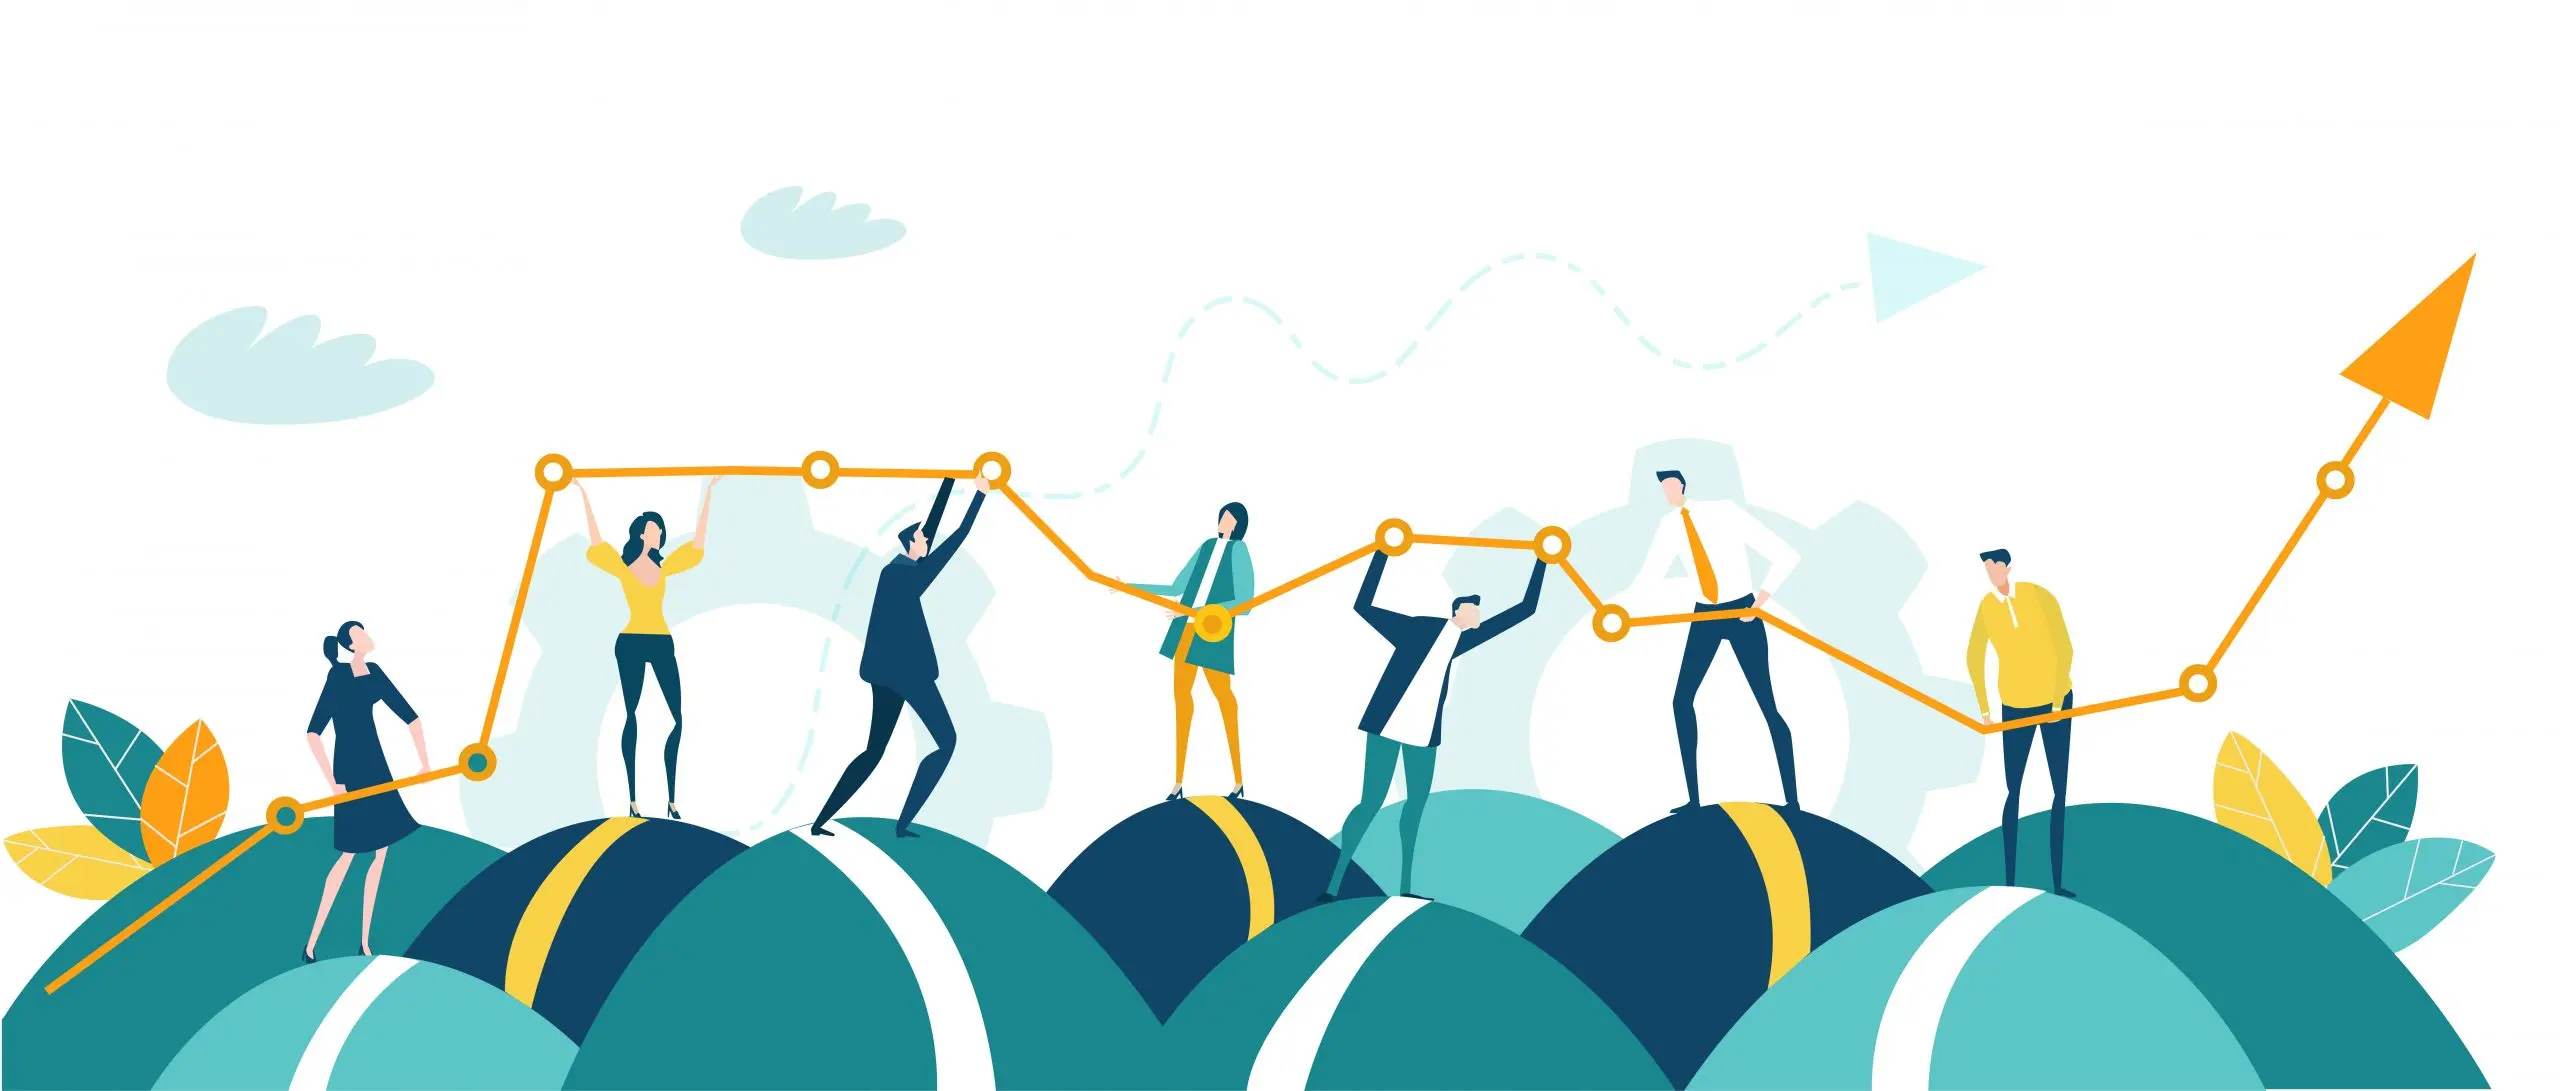

Las Series de Tiempo representan una evolución natural del modelado de datos. Mientras que en la regresión estándar tratamos cada observación como un evento independiente, en las series de tiempo el orden cronológico es la característica fundamental. Aquí, el pasado no solo es información histórica, sino el motor que predice el futuro.

¿Qué es una Serie de Tiempo?
Una serie de tiempo es una secuencia de puntos de datos medidos en intervalos sucesivos y, generalmente, iguales de tiempo. A diferencia de los datos transversales (donde analizamos múltiples sujetos en un solo momento), aquí analizamos un solo sujeto a través del tiempo.

Los 4 Componentes Clave
Para que una red neuronal o un modelo estadístico comprenda una serie de tiempo, debe ser capaz de descomponerla en:

Tendencia (Trend): El movimiento de larga duración (ascendente, descendente o plano) de los datos.

Estacionalidad (Seasonality): Patrones que se repiten en intervalos fijos (como el aumento de ventas en Navidad o el calor en verano).

Ciclo: Fluctuaciones de larga duración que no tienen un periodo fijo (como los ciclos económicos).

Ruido o Irregularidad: Variaciones aleatorias e impredecibles que no siguen un patrón.

https://suameca.banrep.gov.co/estadisticas-economicas/informacionSerie/1/tasa_cambio_peso_colombiano_trm_dolar_usd

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    Dataset = pd.read_excel(filename)

Dataset.head(7)

Saving Datos_TRM_Ajustados.xlsx to Datos_TRM_Ajustados.xlsx


,TRM Actual,TRM mes pasado,TRM hace dos meses,TRM del siguiente mes
0,4539.54,4526.03,4760.96,4213.53
1,4526.03,4760.96,4802.75,4539.54
2,4760.96,4802.75,4712.18,4526.03
3,4802.75,4712.18,4787.89,4760.96
4,4712.18,4787.89,4922.30,4802.75
5,4787.89,4922.30,4714.96,4712.18
6,4922.30,4714.96,4437.31,4787.89


In [ ]:
#Ajustando los datos a una matriz numérica
import numpy as np
Dataset_Matriz = np.array(Dataset)
#Dividiendo los datos en entrada y salida
Entradas = Dataset_Matriz[:,0:3]
Salida = Dataset_Matriz[:,-1]

Entrenando los modelos (En este caso entrenamos dos modelos)

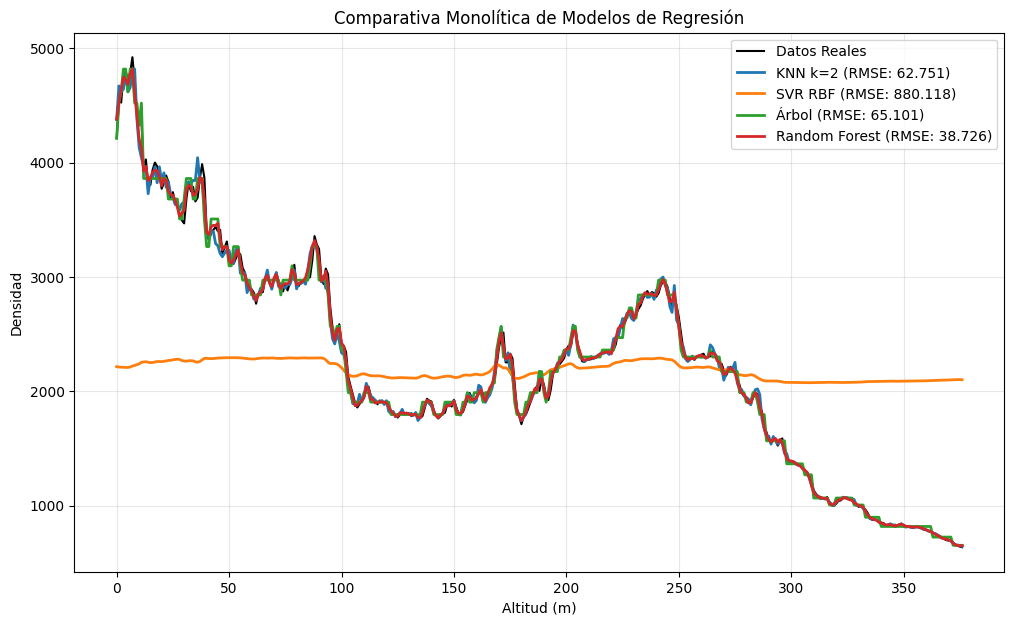

----------------------------------------
MODELO                    | RMSE      
----------------------------------------
KNN (k=2)                 | 62.7510
SVR (RBF)                 | 880.1182
Árbol de Decisión         | 65.1008
Random Forest             | 38.7257
----------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. DATOS ORIGINALES
X_poly = Entradas
Y = Salida

# 2. PREPARACIÓN DE CARACTERÍSTICAS ( Escalamiento)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# 3. ENTRENAMIENTO Y PREDICCIÓN DE MODELOS

# Modelo 1: Polyfit (Numpy)


# Modelo 2: KNN (k=2)
knn = KNeighborsRegressor(n_neighbors=2)
knn.fit(X_poly_scaled, Y)
Y_pred_knn = knn.predict(X_poly_scaled)
_,rmse_knn = Cal_error(Y, Y_pred_knn)

# Modelo 3: SVR (Support Vector Regression)
svr = SVR(kernel='rbf', C=1.0, epsilon=0.01)
svr.fit(X_poly_scaled, Y)
Y_pred_svr = svr.predict(X_poly_scaled)
_,rmse_svr = Cal_error(Y, Y_pred_svr)

# Modelo 4: Árbol de Decisión
tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X_poly_scaled, Y)
Y_pred_tree = tree.predict(X_poly_scaled)
_,rmse_tree = Cal_error(Y, Y_pred_tree)

# Modelo 5: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_poly_scaled, Y)
Y_pred_rf = rf.predict(X_poly_scaled)
_,rmse_rf = Cal_error(Y, Y_pred_rf)

# 4. VISUALIZACIÓN UNIFICADA
plt.figure(figsize=(12, 7))
plt.plot(Y, color='black',  label='Datos Reales')

plt.plot(Y_pred_knn, label=f'KNN k=2 (RMSE: {rmse_knn:.3f})', linewidth=2)
plt.plot(Y_pred_svr, label=f'SVR RBF (RMSE: {rmse_svr:.3f})', linewidth=2)
plt.plot(Y_pred_tree, label=f'Árbol (RMSE: {rmse_tree:.3f})', linewidth=2)
plt.plot(Y_pred_rf, label=f'Random Forest (RMSE: {rmse_rf:.3f})', linewidth=2)

plt.title('Comparativa Monolítica de Modelos de Regresión')
plt.xlabel('Altitud (m)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. REPORTE DE ERRORES
print("-" * 40)
print(f"{'MODELO':<25} | {'RMSE':<10}")
print("-" * 40)
print(f"{'KNN (k=2)':<25} | {rmse_knn:.4f}")
print(f"{'SVR (RBF)':<25} | {rmse_svr:.4f}")
print(f"{'Árbol de Decisión':<25} | {rmse_tree:.4f}")
print(f"{'Random Forest':<25} | {rmse_rf:.4f}")
print("-" * 40)

Utilizando el modelo entrenado

In [ ]:
#Se ingresan los datos de entrada para generar una predicción
Nueva_entrada = np.zeros((1,3))
Nueva_entrada[0,0]=float(input('Ingrese el valor de la TRM actual: '))
Nueva_entrada[0,1]=float(input('Ingrese el valor de la TRM pasada: '))
Nueva_entrada[0,2]=float(input('Ingrese el valor de la TRM hace dos meses: '))

Proyeccion_1 = tree.predict(Nueva_entrada)
Proyeccion_2 = knn.predict(Nueva_entrada)

print('')
print('')
print('Según los datos ingresados, la proyecciòn de la TRM para el siguiente mes usando KNN serà: ',Proyeccion_1[0])
print('')
print('Según los datos ingresados, la proyecciòn de la TRM para el siguiente mes usando ANN serà: ',Proyeccion_2[0])

Ingrese el valor de la TRM actual: 3680
Ingrese el valor de la TRM pasada: 3750
Ingrese el valor de la TRM hace dos meses: 3500


Según los datos ingresados, la proyecciòn de la TRM para el siguiente mes usando KNN serà:  4619.105

Según los datos ingresados, la proyecciòn de la TRM para el siguiente mes usando ANN serà:  4757.465


#Actividad

Tomar una de las tasas de cambio del dólar en el siguiente dataset. Luego modelar según alguna regla de datos pasados y horizonte de pronóstico.

https://www.kaggle.com/datasets/federalreserve/exchange-rates

Este trabajo se puede hacer en parejas, y se entrega en Notebook más los datos. La idea es que el modelo ajuste bien y que las predicciones sean muy aterrizadas a la realidad.